In [25]:
from omegaconf import OmegaConf 
cfg = OmegaConf.load("configs/xgb_sarimax_debug.yaml")

In [30]:
from modeling.data.master import build_daily
from modeling.features import assemble_features
from modeling.metrics import mae, rmse, poisson_deviance
from modeling.models import build_model
from modeling.split import make_split
from modeling.evaluate import _load_run
import pickle
from types import SimpleNamespace


In [32]:
cfg = OmegaConf.create({'load_model': 'ward3_xgb_sarimax_20200601_20251231_20260319_568d1b36'})
model_path, run_cfg = _load_run(cfg)
with open(model_path, "rb") as f:
    saved = pickle.load(f)
model = saved["model"]
feature_cols = saved["feature_cols"]
feat_params = SimpleNamespace(**saved["feat_params"])

In [38]:
pothole_df, weather_df = build_daily(run_cfg)
feat_df = assemble_features(pothole_df, weather_df, feat_params)
feat_df = make_split(feat_df, run_cfg.split)


[assemble_features] kept 1821/1826 rows (99.7%) after dropping NaNs


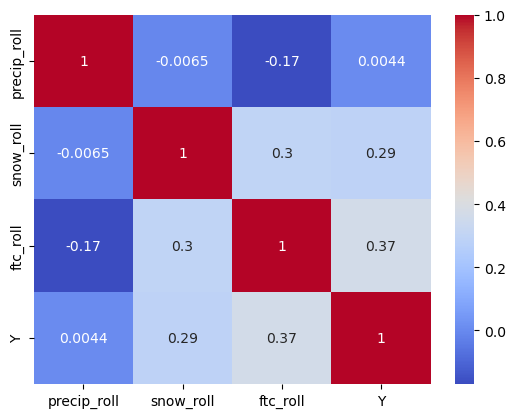

In [39]:
# get correlation matrix for precip, snow, ftc: 
import seaborn as sns
import matplotlib.pyplot as plt

# Create a correlation matrix
sns.heatmap(feat_df[['precip_roll', 'snow_roll', 'ftc_roll', 'Y']].corr(), annot=True, cmap='coolwarm')
plt.show()



In [ ]:
test_df = feat_df[feat_df["split"] == "test"]
X_test = test_df[feature_cols]
y_test = test_df["Y"].values

In [41]:
train_val_df = feat_df[feat_df["split"].isin(["train", "val"])] # get the train and val set
X_tv = train_val_df[feature_cols]
y_tv = train_val_df["Y"] # get the target for the train and val set

In [42]:
# predict on the test set: 
y_test_preds = model.predict(X_test)
# predict on the train and val set: 
y_train_preds = model.predict(X_tv)


In [43]:
# append trains and predicteds: 
import numpy as np
y_true = np.concatenate([y_tv.values, y_test.values], axis=0)
y_pred_full = np.concatenate([y_train_preds, y_test_preds], axis=0)


# plot the residuals: 


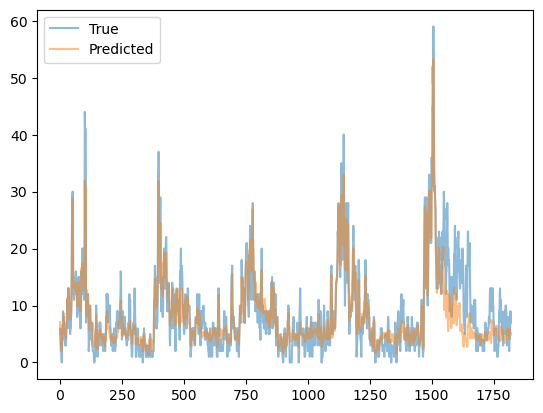

In [44]:
plt.plot(y_true, alpha=0.5, label='True')
plt.plot(y_pred_full, alpha=0.5, label='Predicted')
plt.legend()
plt.show()

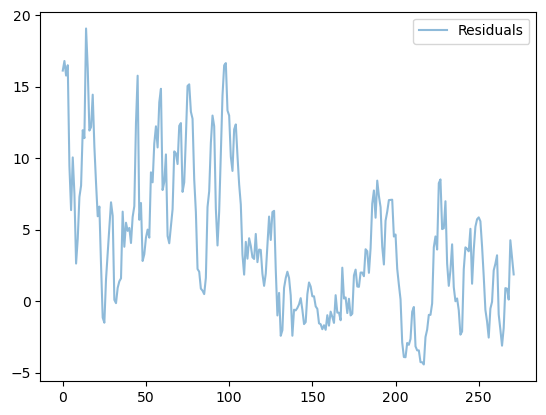

In [45]:
residuals = y_true - y_pred_full
plt.plot(residuals[-272:], alpha=0.5, label='Residuals')
plt.legend()
plt.show()


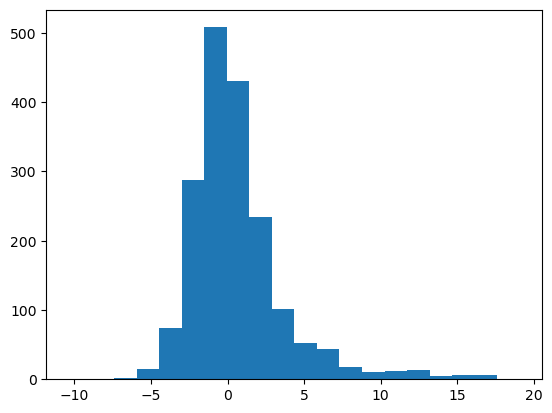

In [46]:
# distribution of residuals: 
z_residuals = (residuals - residuals.mean()) / residuals.std()
plt.hist(residuals, bins=20)
plt.show()
